# Микроструктура рынка

Визуализация микроструктуры рыночного симулятора на примере 1 симуляции

In [ ]:
%matplotlib inline
import os, sys
from pathlib import Path

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.analysis import load, metrics, plots

LOGS_BASE = Path(PROJECT_ROOT) / 'experiments' / 'log'

RUN_NAME = 'baseline_seed48'

def _has_full_logs(run_dir):
    return any(run_dir.glob('ORDERBOOK_*.bz2'))

if RUN_NAME is None:
    candidates = [p for p in LOGS_BASE.iterdir() if p.is_dir() and _has_full_logs(p)]
    if not candidates:
        raise RuntimeError(
            f'Нет runs с полным логированием в {LOGS_BASE}.\n'
            'Запусти baseline без --fast-mode:\n'
            '  cd experiments && PYTHONPATH="../vendor/abides:.." \\\n'
            '    python ../src/scenarios/multimarket_baseline.py --log-dir my_run'
        )
    RUN_NAME = max(candidates, key=lambda p: p.stat().st_mtime).name

print('Run name:', RUN_NAME)
print('Agents:  ', len(load.list_agents(RUN_NAME, base=LOGS_BASE)))

Run name: baseline_seed48
Agents:   4374


## 1. Bid / Ask / Mid

График bid / ask / mid цен на всех 3 рынках

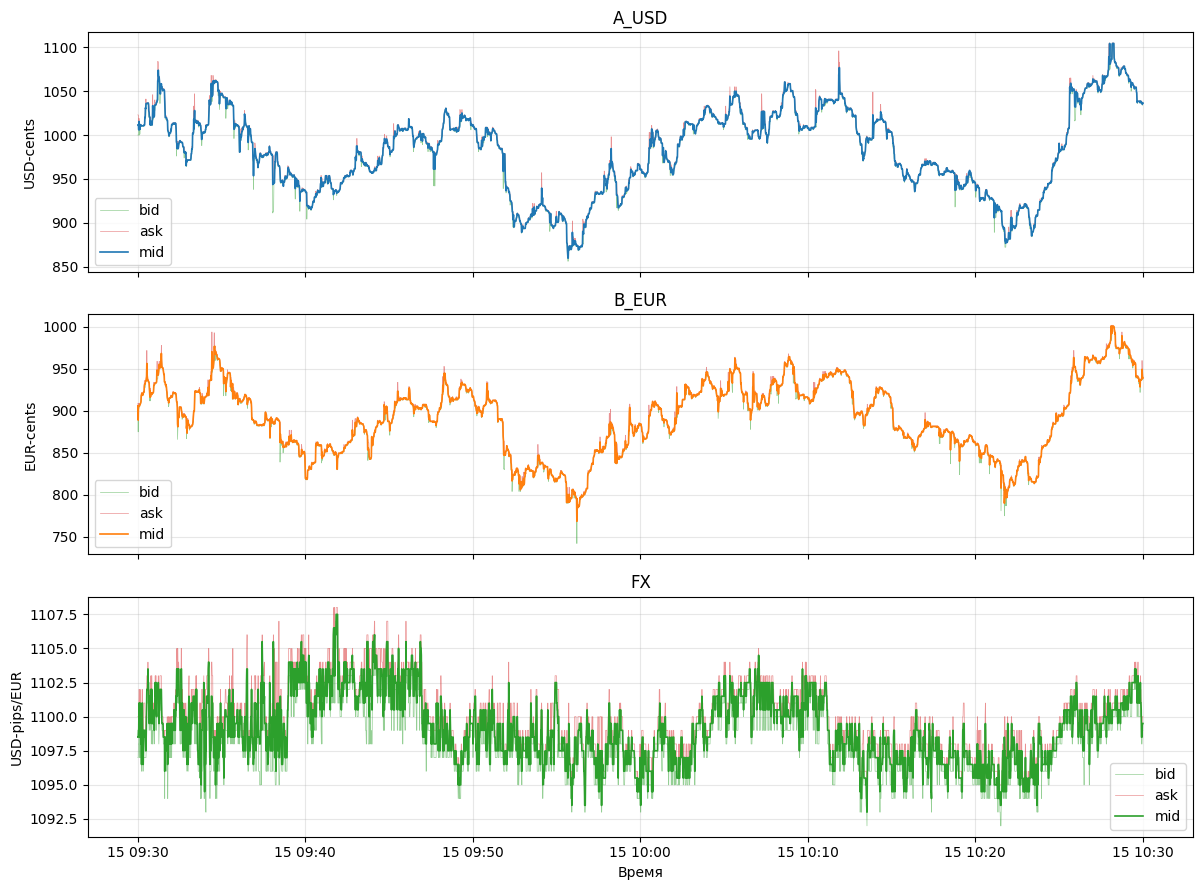

In [ ]:
fig = plots.plot_bid_ask_mid(RUN_NAME, base=LOGS_BASE)
plt.show()

## 2. Market mid vs Fundamental

График mid и фундаментальной цен на рынках обоих активов

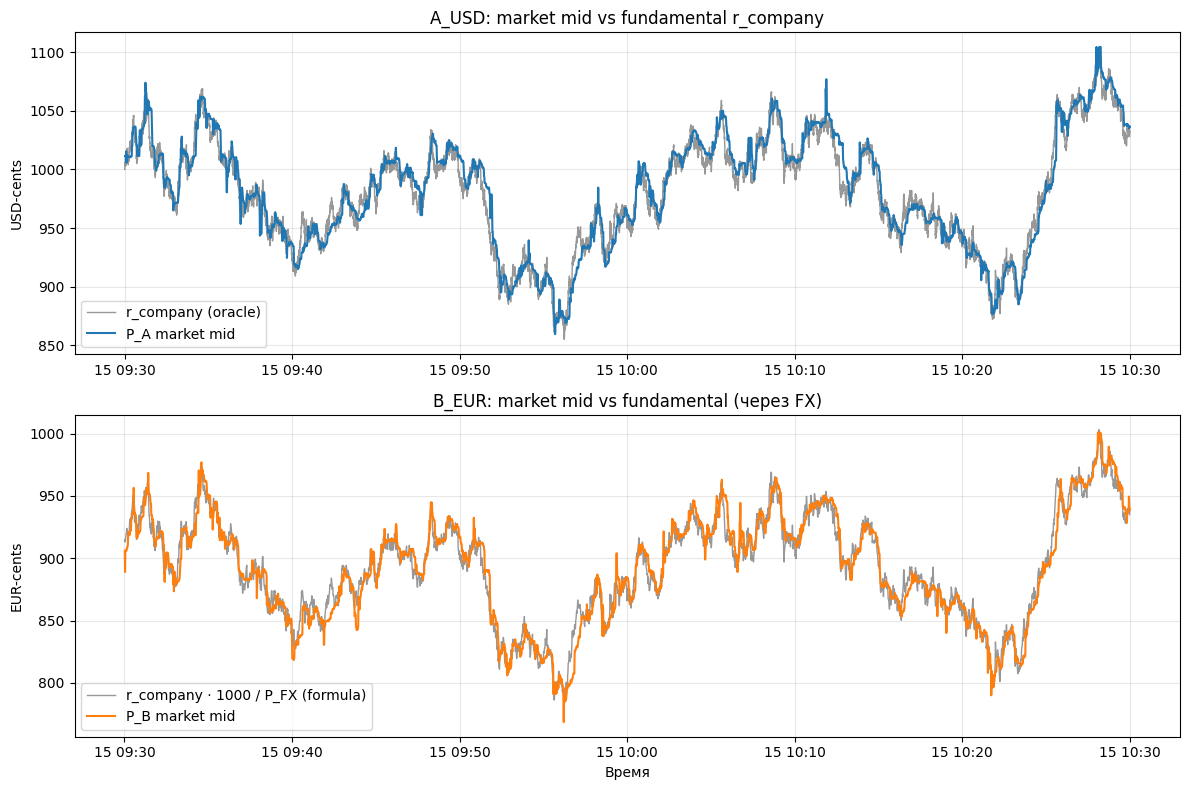

In [ ]:
fig = plots.plot_fundamental_vs_market(RUN_NAME, base=LOGS_BASE)
plt.show()

## 3. Объём торгов по типу агента во времени

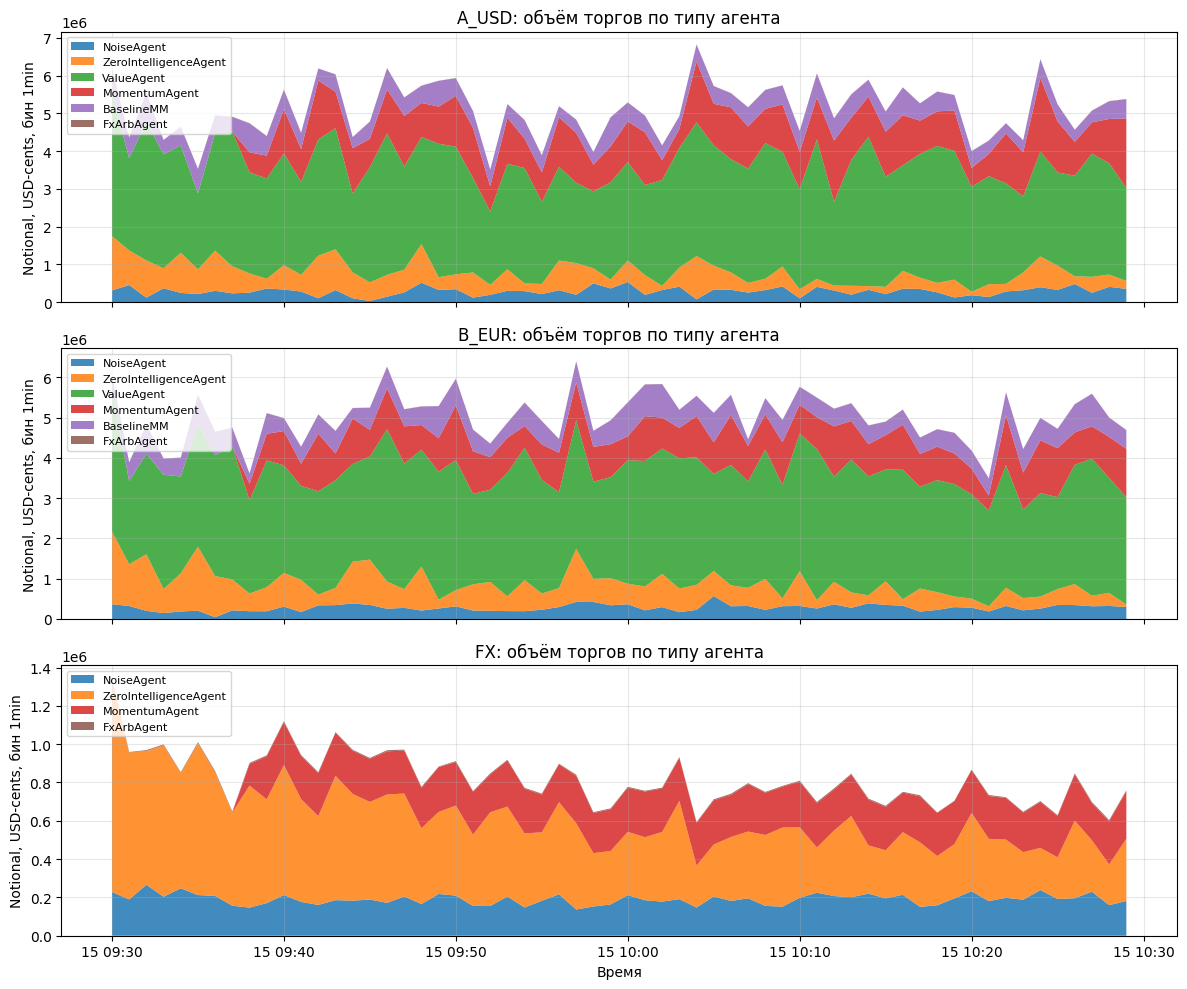

In [ ]:
fig = plots.plot_volume_by_agent_type(RUN_NAME, base=LOGS_BASE, freq='1min')
plt.show()

### Сводка объёмов по типу агента

In [ ]:
df_exec = metrics.parse_executions(load, RUN_NAME, base=LOGS_BASE)
print(f'Total exec events: {len(df_exec):,}  (matched trade = 2 events: buyer + seller)\n')

g = df_exec.groupby(['symbol', 'agent_type']).agg(
    n_trades=('quantity', 'count'),
    qty_total=('quantity', 'sum'),
    notional_total_usd=('notional_usd_cents', lambda s: s.sum() / 100),
)

g['notional_share_%'] = g.groupby(level='symbol')['notional_total_usd'].transform(lambda s: 100 * s / s.sum())
g = g.sort_values(['symbol', 'notional_total_usd'], ascending=[True, False])

display(g.style.format({
    'qty_total':          '{:>10,.0f}',
    'notional_total_usd': '${:>14,.0f}',
    'notional_share_%':   '{:>5.1f}%',
}))

Total exec events: 46,608  (matched trade = 2 events: buyer + seller)

